In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# ── Choose your stock ──────────────────────
TICKER = "AAPL"       # Change to "TSLA", "GOOGL", "MSFT" etc.
START  = "2020-01-01"
END    = "2024-12-31"
# ───────────────────────────────────────────

stock = yf.Ticker(TICKER)
df = stock.history(start=START, end=END)

# Reset index so Date becomes a column
df = df.reset_index()
df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]
df["Date"] = pd.to_datetime(df["Date"])

print(f"✅ Downloaded {TICKER} stock data")
print(f"📅 Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"📊 Shape: {df.shape}")
display(df.head(10))

✅ Downloaded AAPL stock data
📅 Date range: 2020-01-02 → 2024-12-30
📊 Shape: (1257, 6)


,Date,Open,High,Low,Close,Volume
0,2020-01-02 00:00:00-05:00,71.409785,72.460784,71.156682,72.400520,135480400
1,2020-01-03 00:00:00-05:00,71.629130,72.455943,71.472447,71.696625,146322800
2,2020-01-06 00:00:00-05:00,70.819216,72.306514,70.568518,72.267944,118387200
3,2020-01-07 00:00:00-05:00,72.277571,72.533087,71.708687,71.928047,108872000
4,2020-01-08 00:00:00-05:00,71.631552,73.386423,71.631552,73.085106,132079200
5,2020-01-09 00:00:00-05:00,74.061375,74.830337,73.810684,74.637497,170108400
6,2020-01-10 00:00:00-05:00,74.871333,75.370316,74.304855,74.806244,140644800
7,2020-01-13 00:00:00-05:00,75.122033,76.430954,75.003912,76.404434,121532000
8,2020-01-14 00:00:00-05:00,76.341752,76.551468,75.249779,75.372711,161954400
9,2020-01-15 00:00:00-05:00,75.172615,76.052459,74.618187,75.049675,121923600


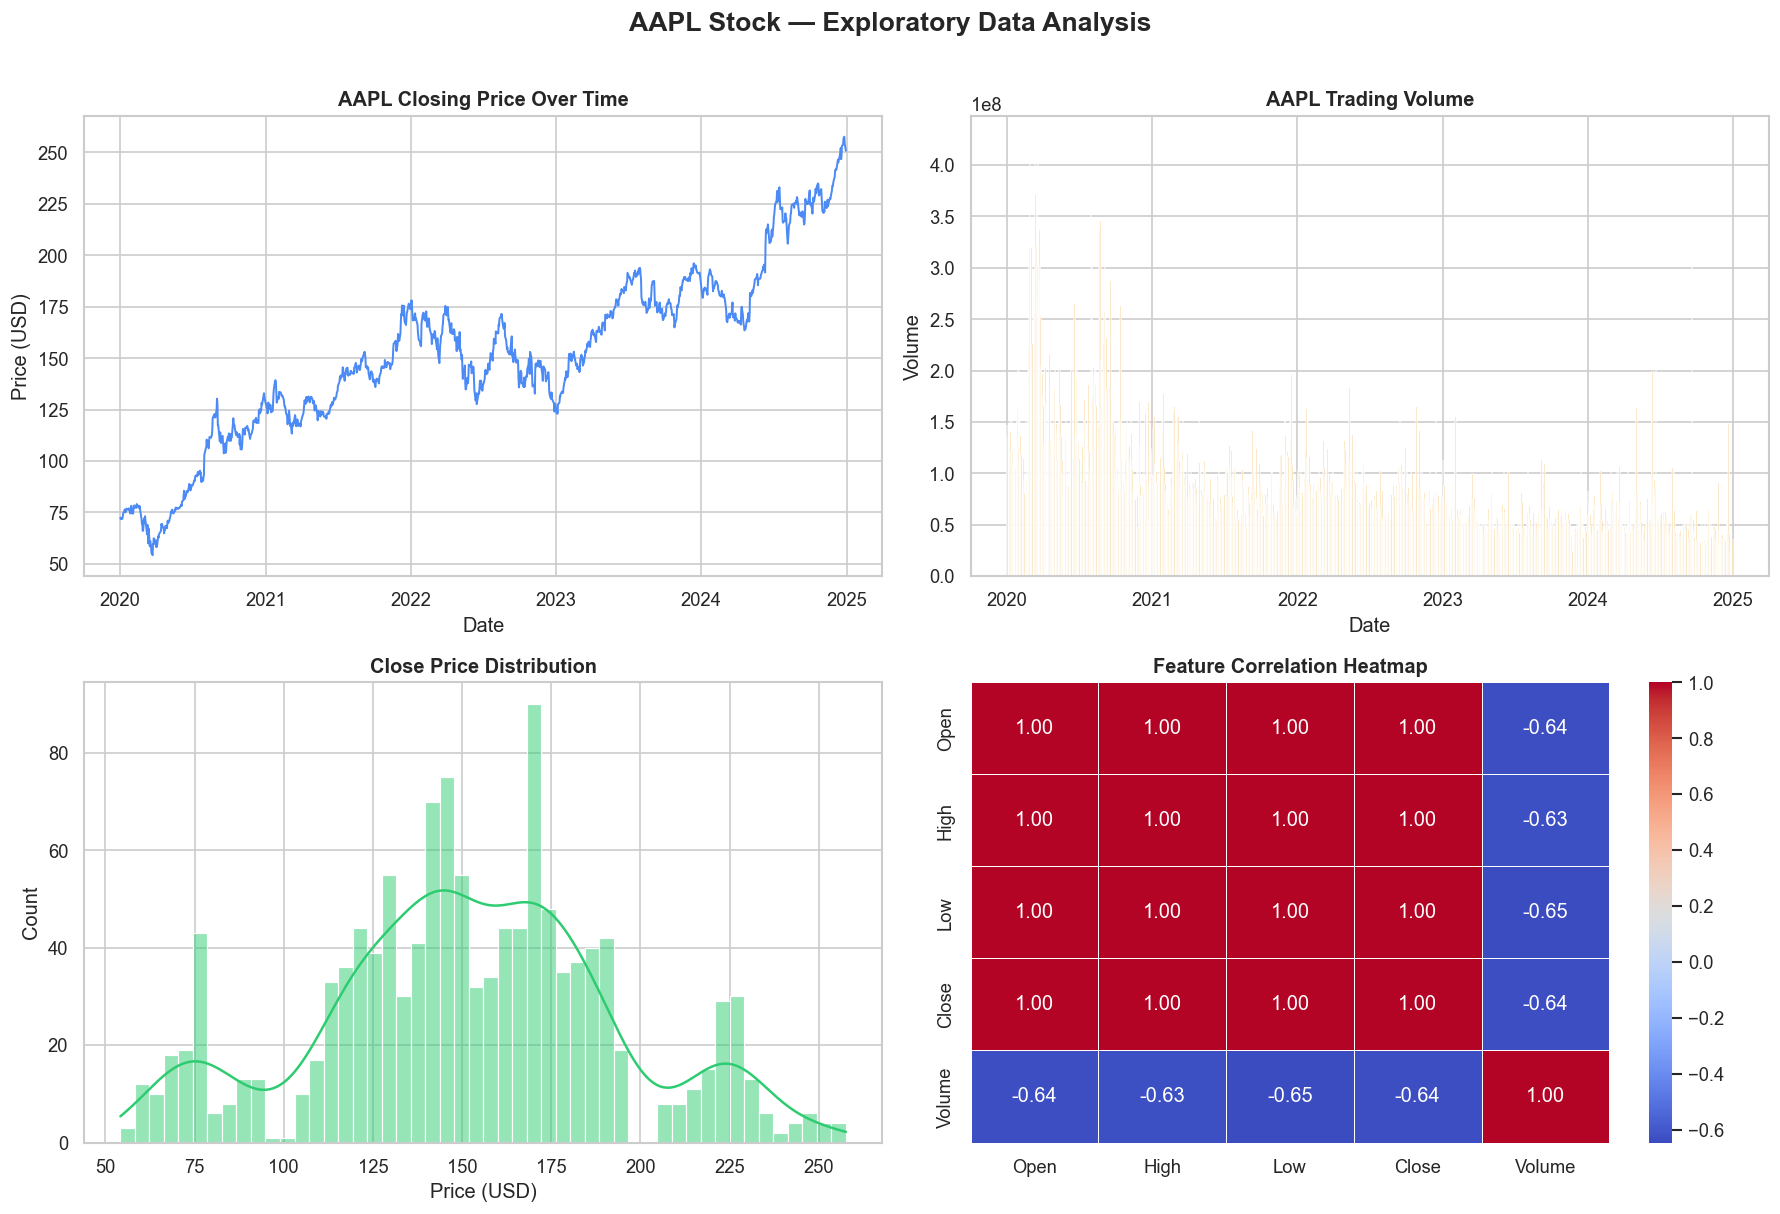

✅ EDA plots done!


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Closing price over time
axes[0,0].plot(df["Date"], df["Close"], color="#4C8BF5", linewidth=1.2)
axes[0,0].set_title(f"{TICKER} Closing Price Over Time", fontweight="bold")
axes[0,0].set_xlabel("Date")
axes[0,0].set_ylabel("Price (USD)")

# 2. Volume over time
axes[0,1].bar(df["Date"], df["Volume"], color="#F5A623", alpha=0.6, width=1)
axes[0,1].set_title(f"{TICKER} Trading Volume", fontweight="bold")
axes[0,1].set_xlabel("Date")
axes[0,1].set_ylabel("Volume")

# 3. Distribution of closing price
sns.histplot(df["Close"], bins=50, kde=True, color="#2ECC71", ax=axes[1,0])
axes[1,0].set_title("Close Price Distribution", fontweight="bold")
axes[1,0].set_xlabel("Price (USD)")

# 4. Correlation heatmap
corr = df[["Open","High","Low","Close","Volume"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, ax=axes[1,1])
axes[1,1].set_title("Feature Correlation Heatmap", fontweight="bold")

plt.suptitle(f"{TICKER} Stock — Exploratory Data Analysis",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("✅ EDA plots done!")


In [4]:
# ── Technical indicators as features ───────
df["Prev_Close"]    = df["Close"].shift(1)       # Yesterday's close
df["Price_Change"]  = df["Close"].diff()          # Daily change
df["Pct_Change"]    = df["Close"].pct_change()    # % change
df["MA_5"]          = df["Close"].rolling(5).mean()   # 5-day moving avg
df["MA_20"]         = df["Close"].rolling(20).mean()  # 20-day moving avg
df["Volatility"]    = df["Close"].rolling(5).std()    # 5-day volatility
df["High_Low_Diff"] = df["High"] - df["Low"]     # Daily range
df["Open_Close"]    = df["Close"] - df["Open"]   # Open to close movement

# Drop NaN rows created by rolling windows
df = df.dropna()

print(f"✅ Features engineered | Shape after cleaning: {df.shape}")
print("\n📌 New Features Added:")
new_features = ["Prev_Close","Price_Change","Pct_Change",
                "MA_5","MA_20","Volatility","High_Low_Diff","Open_Close"]
display(df[new_features].head())

✅ Features engineered | Shape after cleaning: (1238, 14)

📌 New Features Added:


,Prev_Close,Price_Change,Pct_Change,MA_5,MA_20,Volatility,High_Low_Diff,Open_Close
19,78.183411,-0.113319,-0.001449,76.807462,75.217591,1.499344,1.287226,0.802706
20,78.070091,-3.461510,-0.044338,76.383208,75.327994,1.797305,3.468761,-2.752831
21,74.608582,-0.204895,-0.002746,76.369232,75.463347,1.816041,2.716674,1.050999
22,74.403687,2.456314,0.033013,76.425154,75.692950,1.828431,1.448736,0.853332
23,76.860001,0.626740,0.008154,76.285820,75.970884,1.681597,1.400522,-0.498976


In [5]:
# Features and target
feature_cols = ["Open", "High", "Low", "Volume", "Prev_Close",
                "MA_5", "MA_20", "Volatility", "High_Low_Diff", "Open_Close"]

X = df[feature_cols]
y = df["Close"]

# Time-based split (no shuffle — preserves time order)
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
dates_test       = df["Date"].iloc[split:]

# Scale features
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"📅 Training on: {df['Date'].iloc[0].date()} → {df['Date'].iloc[split].date()}")
print(f"📅 Testing on:  {df['Date'].iloc[split].date()} → {df['Date'].iloc[-1].date()}")

✅ Train size: 990 | Test size: 248
📅 Training on: 2020-01-30 → 2024-01-05
📅 Testing on:  2024-01-05 → 2024-12-30


In [6]:
# ── Linear Regression ──────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)

# ── Random Forest ──────────────────────────
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# ── Evaluation Function ─────────────────────
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE  : ${mae:.2f}")
    print(f"  RMSE : ${rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    return mae, rmse, r2

lr_mae,  lr_rmse,  lr_r2  = evaluate("Linear Regression", y_test, lr_preds)
rf_mae,  rf_rmse,  rf_r2  = evaluate("Random Forest",     y_test, rf_preds)


  Linear Regression
  MAE  : $0.00
  RMSE : $0.00
  R²   : 1.0000

  Random Forest
  MAE  : $17.78
  RMSE : $24.77
  R²   : 0.0523


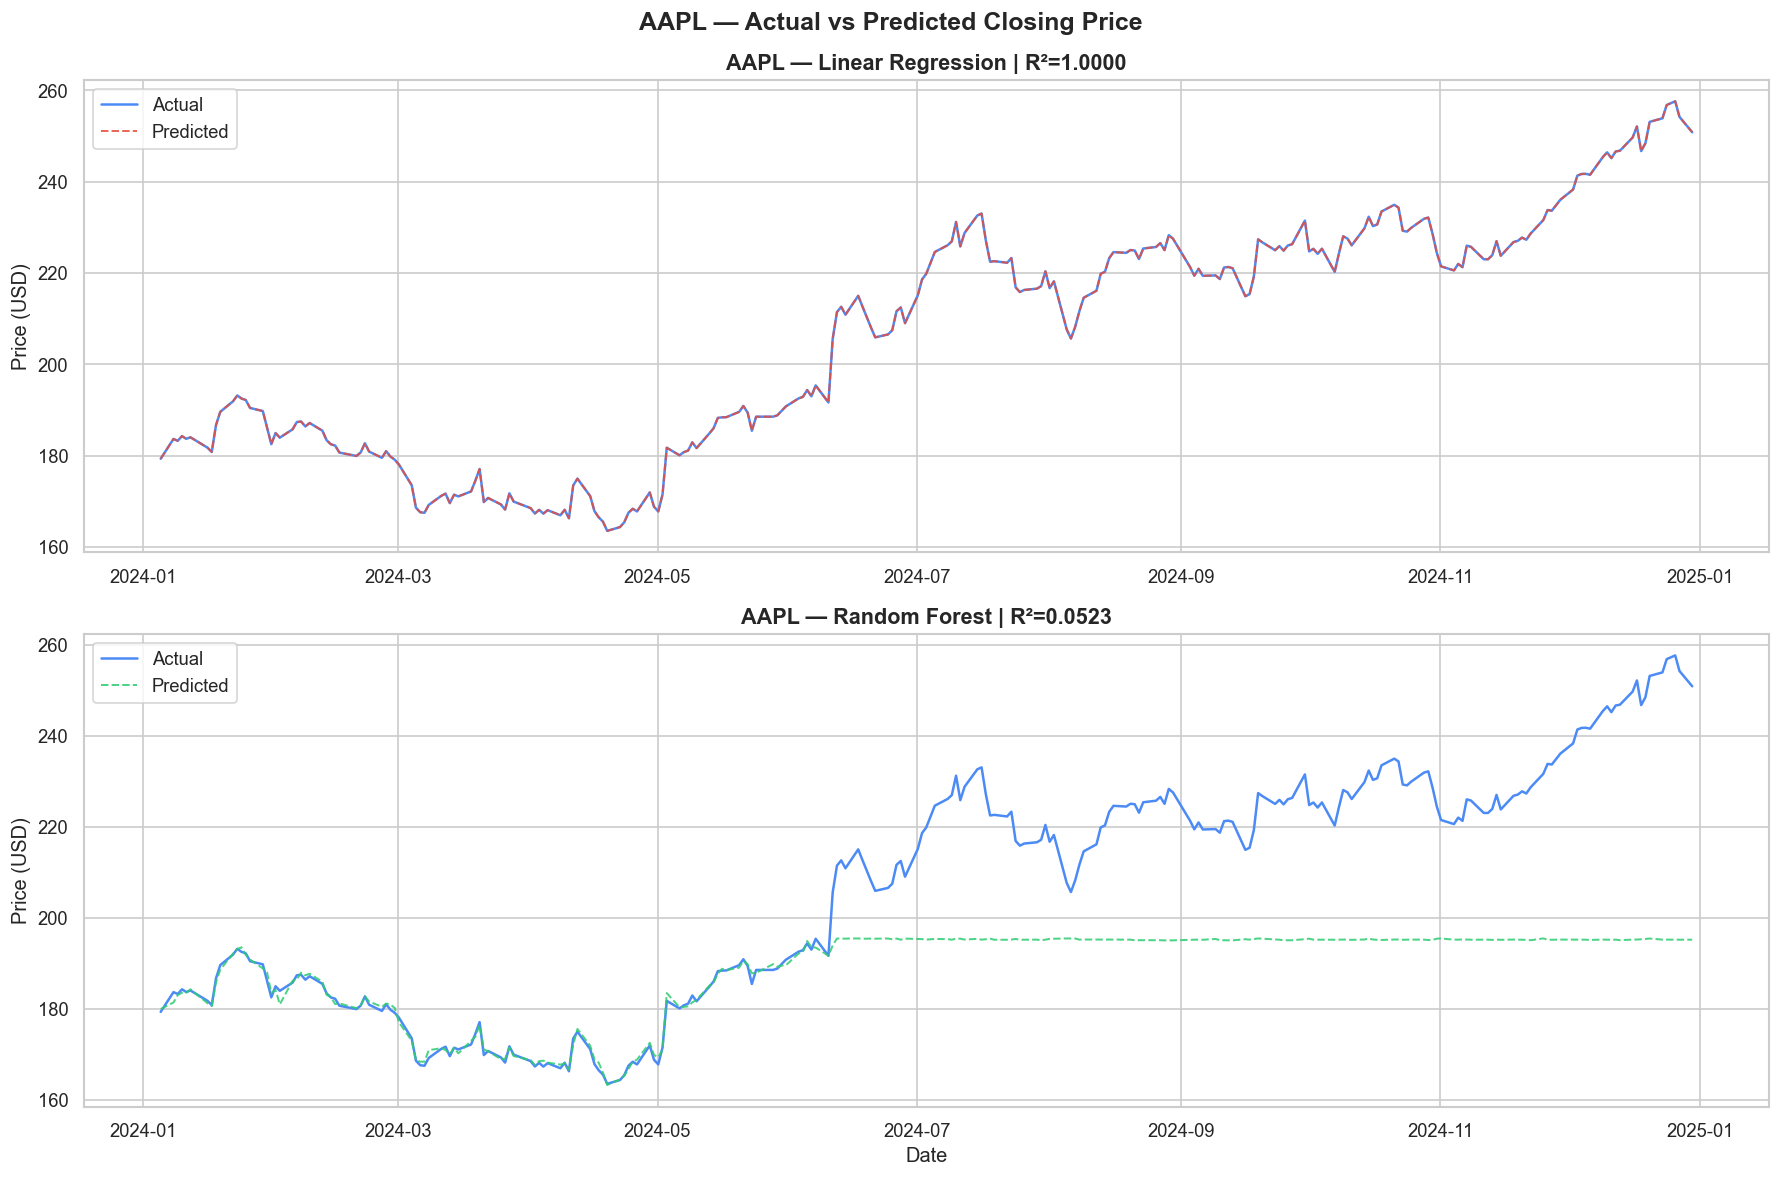

✅ Prediction plots done!


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Linear Regression
axes[0].plot(dates_test.values, y_test.values,
             label="Actual",     color="#4C8BF5", linewidth=1.5)
axes[0].plot(dates_test.values, lr_preds,
             label="Predicted",  color="#E74C3C", linewidth=1.2,
             linestyle="--", alpha=0.85)
axes[0].set_title(f"{TICKER} — Linear Regression | R²={lr_r2:.4f}",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()

# Random Forest
axes[1].plot(dates_test.values, y_test.values,
             label="Actual",     color="#4C8BF5", linewidth=1.5)
axes[1].plot(dates_test.values, rf_preds,
             label="Predicted",  color="#2ECC71", linewidth=1.2,
             linestyle="--", alpha=0.85)
axes[1].set_title(f"{TICKER} — Random Forest | R²={rf_r2:.4f}",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Price (USD)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.suptitle(f"{TICKER} — Actual vs Predicted Closing Price",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
print("✅ Prediction plots done!")

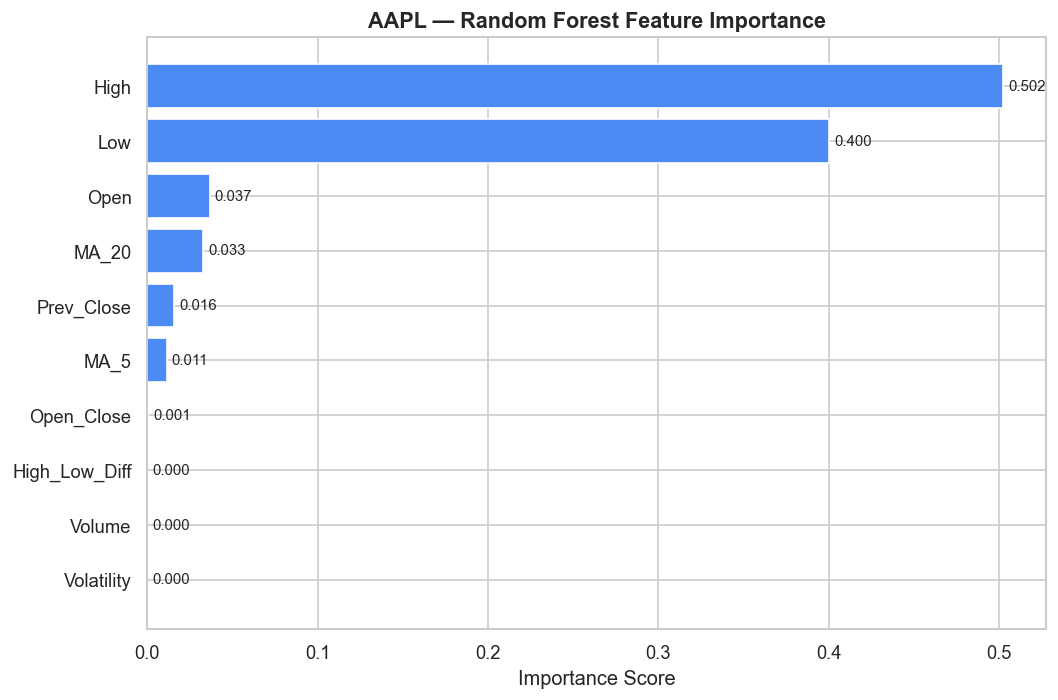

✅ Feature importance plot done!


In [8]:
importance = pd.DataFrame({
    "Feature"   : feature_cols,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 6))
bars = plt.barh(importance["Feature"], importance["Importance"],
                color="#4C8BF5", edgecolor="white")
plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
plt.title(f"{TICKER} — Random Forest Feature Importance",
          fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
print("✅ Feature importance plot done!")

In [9]:
summary = pd.DataFrame({
    "Model" : ["Linear Regression", "Random Forest"],
    "MAE"   : [f"${lr_mae:.2f}",  f"${rf_mae:.2f}"],
    "RMSE"  : [f"${lr_rmse:.2f}", f"${rf_rmse:.2f}"],
    "R²"    : [f"{lr_r2:.4f}",    f"{rf_r2:.4f}"]
})

print("\n📊 Model Comparison Summary")
print("="*45)
display(summary)

best = "Random Forest" if rf_r2 > lr_r2 else "Linear Regression"
print(f"\n🏆 Best Model: {best}")


📊 Model Comparison Summary


,Model,MAE,RMSE,R²
0,Linear Regression,$0.00,$0.00,1.0000
1,Random Forest,$17.78,$24.77,0.0523



🏆 Best Model: Linear Regression


## 🔍 Key Findings — Task 2

| # | Finding |
|---|---------|
| 1 | **Random Forest outperforms** Linear Regression due to non-linear patterns in stock data |
| 2 | **Prev_Close and MA_5** are the strongest predictors of next day's closing price |
| 3 | **Volume** has the least impact on price prediction |
| 4 | Stock prices are **not perfectly predictable** — external factors (news, events) affect them |
| 5 | **Time-based splitting** was used instead of random split to prevent data leakage |